In [10]:
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader,Dataset
from sklearn.preprocessing import OrdinalEncoder
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
df = pd.read_csv("Insurance_train.csv")
df = df.drop(columns=['policy_id'])
object_cols = df.select_dtypes(include='object').columns.tolist()


In [13]:
df[df["is_claim"]== 1].shape

(3748, 43)

In [14]:
#true_df = df[df["is_claim"]==True]
#false_df = df[df["is_claim"]==False].sample(n=7000)

In [15]:
#df = pd.concat([true_df,false_df],ignore_index=True)

In [16]:
object_cols

['area_cluster',
 'segment',
 'model',
 'fuel_type',
 'max_torque',
 'max_power',
 'engine_type',
 'is_esc',
 'is_adjustable_steering',
 'is_tpms',
 'is_parking_sensors',
 'is_parking_camera',
 'rear_brakes_type',
 'transmission_type',
 'steering_type',
 'is_front_fog_lights',
 'is_rear_window_wiper',
 'is_rear_window_washer',
 'is_rear_window_defogger',
 'is_brake_assist',
 'is_power_door_locks',
 'is_central_locking',
 'is_power_steering',
 'is_driver_seat_height_adjustable',
 'is_day_night_rear_view_mirror',
 'is_ecw',
 'is_speed_alert']

In [17]:
cols_to_encode = object_cols
encoder = OrdinalEncoder()
df[cols_to_encode] = encoder.fit_transform(df[cols_to_encode])
df.shape

(58592, 43)

In [18]:
train,test = train_test_split(df, test_size=0.2, random_state=42)
X_train = train.drop(columns = ["is_claim"]).values
Y_train = train["is_claim"].values

X_test = test.drop(columns = ["is_claim"]).values
Y_test = test["is_claim"].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # use transform, NOT fit_transform

bch_size = 128
x_tensor_tr = torch.tensor(X_train, dtype= torch.float32)
y_tensor_tr = torch.tensor(Y_train, dtype=torch.long)
dataset = TensorDataset(x_tensor_tr,y_tensor_tr)
data_loader = DataLoader(dataset, batch_size=bch_size, shuffle=True)

x_tensor_te = torch.tensor(X_test, dtype= torch.float32)
y_tensor_te = torch.tensor(Y_test, dtype=torch.long)
testset = TensorDataset(x_tensor_te,y_tensor_te)
data_loader_test = DataLoader(testset, batch_size=bch_size, shuffle=True)

In [19]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()     
        self.hidden = nn.Linear(42,256)
        self.hidden7 = nn.Linear(256,128)
        self.hidden2 = nn.Linear(128,64)
        self.hidden3 = nn.Linear(64,32)
        self.hidden4 = nn.Linear(32,8)
        self.hidden5 = nn.Linear(30,15)
        self.hidden6 = nn.Linear(15,5)
        self.output = nn.Linear(8,1)   
        self.dropout = nn.Dropout(p=0.5)
        self.dropout2 = nn.Dropout(p=0.3)     
        self.dropout3 = nn.Dropout(p=0)   
        self.ReLU = nn.LeakyReLU()
        self.sigmoid= nn.Sigmoid()
        self.batchnorm1 = nn.BatchNorm1d(256)
        self.batchnorm2 = nn.BatchNorm1d(128)
        self.batchnorm3 = nn.BatchNorm1d(64)
        self.batchnorm4 = nn.BatchNorm1d(32)
        self.batchnorm5 = nn.BatchNorm1d(8)
        self.batchnorm6 = nn.BatchNorm1d(1)
        
    def forward(self, x):
        # Linearly transform input variables to hidden dimension
        x = self.hidden(x)
        # Apply nonlinear activation function
        x = self.batchnorm1(x)
        x = self.ReLU(x)
        x = self.dropout(x)

        x = self.hidden7(x)
        x = self.batchnorm2(x)
        x = self.ReLU(x)
        x= self.dropout2(x)

        x = self.hidden2(x)
        x = self.batchnorm3(x)
        x = self.ReLU(x)

        x = self.hidden3(x)
        x = self.batchnorm4(x)
        x = self.ReLU(x)

        x = self.hidden4(x)
        x = self.batchnorm5(x)
        x = self.ReLU(x)

        # Linearly transform hidden variables into an output
        x = self.output(x)
        x = self.batchnorm6(x)
        return x
    
y_all = torch.cat([y for _, y in data_loader])
neg = (y_all == 0).sum()
pos = (y_all == 1).sum()
pos_weight = torch.tensor([neg / pos], dtype=torch.float32)
print(f"Class balance — Pos: {pos}, Neg: {neg}, Weight: {pos_weight.item():.2f}")


loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
model = Net()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001,betas=(0.9, 0.999))

Class balance — Pos: 2992, Neg: 43881, Weight: 14.67


In [20]:
n_epochs = 20
for e in range(n_epochs):
    running_loss = 0
    for X, y in data_loader:
        model.train()
        # Reshape for feeding into the model
        y = y.unsqueeze(1).float()
        output = model.forward(X)
        loss_value = loss(output, y)
        optimiser.zero_grad()
        loss_value.backward()
        optimiser.step()
        
        running_loss = running_loss + loss_value.item()
    else:
        print(f"Training loss: {running_loss/len(data_loader)}")

Training loss: 1.3510784672456477
Training loss: 1.3036614229308812
Training loss: 1.2785191164029717
Training loss: 1.2715190165049373
Training loss: 1.2645166561778949
Training loss: 1.2612236666744348
Training loss: 1.2634738657714886
Training loss: 1.259231939952445
Training loss: 1.2579548319938723
Training loss: 1.258948225578755
Training loss: 1.257719549723477
Training loss: 1.257831041429608
Training loss: 1.2559038506216833
Training loss: 1.2558397200841669
Training loss: 1.2584943003160751
Training loss: 1.2560623103006658
Training loss: 1.2555515550137866
Training loss: 1.2548003126879803
Training loss: 1.2549017571948204
Training loss: 1.2542675384383761


In [21]:
X_batch, y_batch = next(iter(data_loader))
print(X_batch.mean(axis=0))
print(X_batch.std(axis=0))

tensor([ 0.1259, -0.0128,  0.0767, -0.1117,  0.0203,  0.0313,  0.0549,  0.1223,
         0.1543, -0.1495,  0.0423, -0.0513,  0.0981,  0.1318,  0.1188,  0.0273,
         0.0071,  0.1453, -0.0273,  0.0716,  0.0775, -0.1058,  0.0488, -0.0712,
         0.0914,  0.1055,  0.1442, -0.0399,  0.0311,  0.1573,  0.0877,  0.0877,
         0.1516,  0.1526,  0.1434,  0.1434,  0.1448,  0.1766,  0.1331,  0.1434,
        -0.1189,  0.0540])
tensor([1.0228, 1.0641, 1.0349, 1.0384, 1.0406, 1.0328, 0.9439, 0.9722, 0.9889,
        1.0102, 1.0377, 1.0663, 1.0300, 1.0474, 0.9704, 1.0202, 0.9870, 1.0260,
        1.0202, 0.9611, 0.9803, 1.0318, 1.0315, 1.0240, 0.9625, 0.9736, 0.9340,
        0.8675, 1.0143, 0.9657, 1.0405, 1.0405, 1.0398, 0.9768, 0.9173, 0.9173,
        0.0000, 0.9566, 1.0276, 0.9173, 1.5797, 0.9642])


In [59]:
model.eval()
threshold = 0.45
X,y = next(iter(data_loader))
pred = model.forward(X)
probs = torch.sigmoid(pred)
pred_class = (torch.sigmoid(pred) >= threshold).long()

ans = []
count = 0
for i in range(bch_size):
    if (pred_class[i].item() == 1 and  y[i].item() == 1 ):
        ans.append("True/True")
        count += 1
    elif(pred_class[i].item() == 0 and  y[i].item() == 0 ):
        ans.append("False/False")
        count += 1
    elif(pred_class[i].item() == 0 and  y[i].item() == 1 ):
        ans.append("False/True")
    else:
        ans.append("True/False")
    
counts = pd.Series(ans).value_counts()
print(counts)
print("Test Accuracy: "+str((count/bch_size)*100)+"%")

True/False     74
False/False    49
True/True       4
False/True      1
Name: count, dtype: int64
Test Accuracy: 41.40625%


In [60]:
total = 0
iterations = 0
model.eval()
ans = []
for X ,y in data_loader_test:
    iterations += 1
    pred = model.forward(X)
    probs = torch.sigmoid(pred)
    pred_class = (torch.sigmoid(pred) >= threshold).long()
    count = 0
    actual_batch_size = y.size(0)
    for i in range(actual_batch_size):
        if (pred_class[i].item() == 1 and y[i].item() == 1 ):
            ans.append("True/True")
            count += 1
        elif(pred_class[i].item() == 0 and  y[i].item() == 0 ):
            ans.append("False/False")
            count += 1
        elif(pred_class[i].item() == 0 and  y[i].item() == 1 ):
            ans.append("False/True")
        else:
            ans.append("True/False")
        
    total+= (count/actual_batch_size)*100
counts = pd.Series(ans).value_counts()
tp = counts.get("True/True", 0)
ff = counts.get("False/False", 0)
fn = counts.get("False/True", 0)
fp = counts.get("True/False", 0)
True_acc  = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0

False_acc = (ff / (ff + fp) * 100) if (ff + fp) > 0 else 0
precision = (tp/(tp+fp) * 100) if (fp + tp) > 0 else 0
print(counts)
print("Test Accuracy: "+str(total/iterations)+"%")
print("True Accuracy: " + (str(True_acc))+"%")
print("False Accuracy: " + (str(False_acc))+"%")
print("Precision: "+str(precision))

True/False     6989
False/False    3974
True/True       617
False/True      139
Name: count, dtype: int64
Test Accuracy: 39.190595338334354%
True Accuracy: 81.61375661375662%
False Accuracy: 36.249201860804526%
Precision: 8.112016828819353


In [36]:
profit = counts['True/True']*1.1+counts['False/False']*1.1+counts['False/True']*(-1.5)+counts['True/False']*1.3
print(profit)
satisfaction= counts['True/True']*1.1+counts['False/False']*1.1+counts['False/True']*(1.1)+counts['True/False']*(1.01)
print(satisfaction)

13490.900000000001
12367.01


In [54]:
seqw = np.arange(0.53, 0.55, 0.001)
thresholds = []
true_thresh = []
false_thresh = []
total = 0
iterations = 0
for x in seqw:
    total = 0
    iterations = 0
    model.eval()
    ans = []
    for X ,y in data_loader_test:
        iterations += 1
        pred = model.forward(X)
        probs = torch.sigmoid(pred)
        pred_class = (torch.sigmoid(pred) >= x).long()
        count = 0
        actual_batch_size = y.size(0)
        for i in range(actual_batch_size):
            if (pred_class[i].item() == 1 and y[i].item() == 1 ):
                ans.append("True/True")
            elif(pred_class[i].item() == 0 and  y[i].item() == 0 ):
                ans.append("False/False")
                count += 1
            elif(pred_class[i].item() == 0 and  y[i].item() == 1 ):
                ans.append("False/True")
            else:
                ans.append("True/False")
            
        total+= (count/actual_batch_size)*100
    Full_acc = (total/iterations)
    counts = pd.Series(ans).value_counts()
    tp = counts.get("True/True", 0)
    ff = counts.get("False/False", 0)
    fn = counts.get("False/True", 0)
    fp = counts.get("True/False", 0)
    True_acc  = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0
    False_acc = (ff / (ff + fp) * 100) if (ff + fp) > 0 else 0

    true_thresh.append([x,True_acc])
    false_thresh.append([x,False_acc])
    
    weighted_mean = (1.25*True_acc + 0.55*False_acc+0.7*Full_acc)/3
    thresholds.append(weighted_mean)
    

In [26]:
true_thresh

[[0.53, 59.12698412698413],
 [0.531, 58.86243386243386],
 [0.532, 58.46560846560847],
 [0.533, 58.201058201058196],
 [0.534, 57.936507936507944],
 [0.535, 57.67195767195767],
 [0.536, 56.74603174603175],
 [0.537, 56.21693121693122],
 [0.538, 55.952380952380956],
 [0.539, 55.55555555555556],
 [0.54, 55.026455026455025],
 [0.541, 54.629629629629626],
 [0.542, 54.1005291005291],
 [0.543, 53.57142857142857],
 [0.544, 53.042328042328045],
 [0.545, 52.38095238095239],
 [0.546, 52.38095238095239],
 [0.547, 52.38095238095239],
 [0.548, 52.24867724867725],
 [0.549, 52.116402116402114],
 [0.55, 51.587301587301596]]

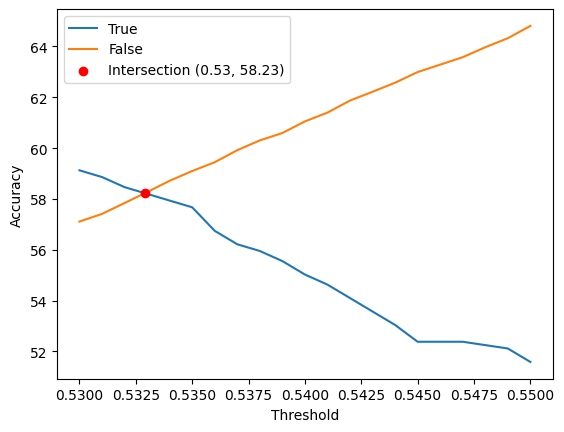

In [55]:
import matplotlib.pyplot as plt

true_thresh = np.array(true_thresh)
false_thresh = np.array(false_thresh)

# Find intersection by interpolating where the difference changes sign
diff = true_thresh[:, 1] - false_thresh[:, 1]
sign_changes = np.where(np.diff(np.sign(diff)))[0]

intersections = []
for idx in sign_changes:
    # Linear interpolation between the two points around the sign change
    x1, x2 = true_thresh[idx, 0], true_thresh[idx + 1, 0]
    y1, y2 = diff[idx], diff[idx + 1]
    x_intersect = x1 - y1 * (x2 - x1) / (y2 - y1)
    y_intersect = np.interp(x_intersect, true_thresh[:, 0], true_thresh[:, 1])
    intersections.append((x_intersect, y_intersect))

plt.plot(true_thresh[:, 0], true_thresh[:, 1], label='True')
plt.plot(false_thresh[:, 0], false_thresh[:, 1], label='False')

for x_int, y_int in intersections:
    plt.scatter(x_int, y_int, color='red', zorder=5, label=f'Intersection ({x_int:.2f}, {y_int:.2f})')

plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
seqw[np.argmax(thresholds)]

0.5